In [12]:
import kagglehub



# Download latest version

path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")



print("Path to dataset files:", path)

Using Colab cache for faster access to the 'lending-club-loan-data-csv' dataset.
Path to dataset files: /kaggle/input/lending-club-loan-data-csv


In [13]:
import pandas as pd
import os

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

if csv_files:
    file_path = os.path.join(path, csv_files[0])

    df = pd.read_csv(file_path, low_memory=False)

    display(df.head())

    print("-" * 50)
    df.info()

else:
    print("ไม่พบไฟล์ .csv ในโฟลเดอร์นี้ ลองตรวจสอบ path ดูอีกครั้ง")

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.0,36 months,13.56,84.92,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.0,60 months,18.94,777.23,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.0,36 months,17.97,180.69,D,D1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,4000,4000,4000.0,36 months,18.94,146.51,D,D2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,30000,30000,30000.0,60 months,16.14,731.78,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), object(36)
memory usage: 2.4+ GB


In [14]:
#เลือกเฉพาะเคสที่รู้ผลลัพธ์แล้ว (จ่ายครบ vs เบี้ยวหนี้)
#ตัดกลุ่ม 'Current' (กำลังผ่อน) ออก เพราะเรายังไม่รู้ว่าอนาคตเขาจะรอดหรือจะทิ้งหนี้
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()

# แปลง Target ให้เป็นตัวเลขเพื่อให้โมเดลคณิตศาสตร์เข้าใจ
# ให้ 'Charged Off' เป็น 1 (สิ่งที่สนใจ)
# ให้ 'Fully Paid' เป็น 0
df['target'] = df['loan_status'].map({'Charged Off': 1, 'Fully Paid': 0})

# คัดเลือกเฉพาะคอลัมน์ (Features) เบื้องต้นที่ฝ่ายสินเชื่อใช้พิจารณา (ป้องกัน Data Leakage)
# เก็บแค่ข้อมูลพื้นฐานที่ควรรู้ก่อนอนุมัติ
features_to_keep = [
    'loan_amnt',      # วงเงินกู้
    'term',           # ระยะเวลากู้ (เช่น 36 หรือ 60 เดือน)
    'int_rate',       # อัตราดอกเบี้ย
    'installment',    # ยอดผ่อนต่อเดือน
    'grade',          # เกรดลูกค้าที่แบงก์ประเมินไว้
    'emp_length',     # อายุงาน
    'home_ownership', # สถานะที่อยู่อาศัย (เช่น เช่า, ผ่อนอยู่, เป็นเจ้าของ)
    'annual_inc',     # รายได้ต่อปี
    'purpose',        # วัตถุประสงค์การกู้
    'dti',            # ภาระหนี้ต่อรายได้ (Debt-to-Income) สำคัญมาก!
    'target'          # ตัวแปรผลลัพธ์ของเรา
]

df_model = df[features_to_keep].copy()

# ดูสัดส่วนของหนี้ดีและหนี้เสีย
print("จำนวนหนี้ดี (0) และ หนี้เสีย (1):")
print(df_model['target'].value_counts())

print("คิดเป็นเปอร์เซ็นต์ (%):")
print(df_model['target'].value_counts(normalize=True) * 100)

จำนวนหนี้ดี (0) และ หนี้เสีย (1):
target
0    1041952
1     261655
Name: count, dtype: int64
คิดเป็นเปอร์เซ็นต์ (%):
target
0    79.928383
1    20.071617
Name: proportion, dtype: float64


In [15]:
# แปลงคอลัมน์ 'term' (ระยะเวลากู้) ให้เป็นตัวเลข
# จาก " 36 months" ให้เหลือแค่ 36
df_model['term'] = df_model['term'].apply(lambda x: int(x[:3]) if pd.notnull(x) else x)

# แปลงคอลัมน์ 'emp_length' (อายุงาน) ให้เป็นตัวเลข
# ใช้ Dictionary ในการจับคู่ (Mapping) ข้อความให้เป็นตัวเลข
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10
}
df_model['emp_length'] = df_model['emp_length'].map(emp_map)

# จัดการค่าว่าง (Missing Values)
# สำหรับตัวเลขที่แหว่งไป (เช่น dti, annual_inc, emp_length) เราจะเติมด้วย "ค่ามัธยฐาน (Median)"
# เพราะ Median ทนทานต่อค่า Outliers (เช่น คนรวยผิดปกติ) ได้ดีกว่าค่าเฉลี่ย (Mean)
for col in ['dti', 'annual_inc', 'emp_length']:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# แปลงตัวหนังสืออื่นๆ ให้เป็นคอลัมน์ย่อยๆ (One-Hot Encoding)
# เปลี่ยน grade A, B, C ให้เป็นคอลัมน์ grade_A (0 หรือ 1), grade_B (0 หรือ 1)
# โมเดลจะได้เข้าใจว่านี่คือหมวดหมู่
categorical_cols = ['grade', 'home_ownership', 'purpose']
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# ตรวจสอบว่ายังมีค่าว่างเหลืออยู่ไหม
print("จำนวนค่าว่างที่เหลืออยู่ในแต่ละคอลัมน์:")
print(df_model.isnull().sum().max()) # ถ้าเป็น 0 แปลว่าคลีนสำเร็จ!

print("หน้าตาข้อมูลปัจจุบัน (ทุกอย่างเป็นตัวเลขแล้ว):")
display(df_model.head())

จำนวนค่าว่างที่เหลืออยู่ในแต่ละคอลัมน์:
0
หน้าตาข้อมูลปัจจุบัน (ทุกอย่างเป็นตัวเลขแล้ว):


,loan_amnt,term,int_rate,installment,emp_length,annual_inc,dti,target,grade_B,grade_C,...,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding
100,30000,36,22.35,1151.16,5.0,100000.0,30.46,0,False,False,...,False,False,False,False,False,False,False,False,False,False
152,40000,60,16.14,975.71,0.0,45000.0,50.53,0,False,True,...,False,False,False,False,False,False,False,False,False,False
170,20000,36,7.56,622.68,10.0,100000.0,18.92,0,False,False,...,False,False,False,False,False,False,False,False,False,False
186,4500,36,11.31,147.99,10.0,38500.0,4.64,0,True,False,...,False,False,False,False,False,False,False,False,False,False
215,8425,36,27.27,345.18,3.0,450000.0,12.37,0,False,False,...,False,False,False,False,False,False,False,False,False,False


จำนวนข้อมูลสำหรับ Train: 160000 บรรทัด
จำนวนข้อมูลสำหรับ Test: 40000 บรรทัด


/tmp/ipykernel_7635/2562450716.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')


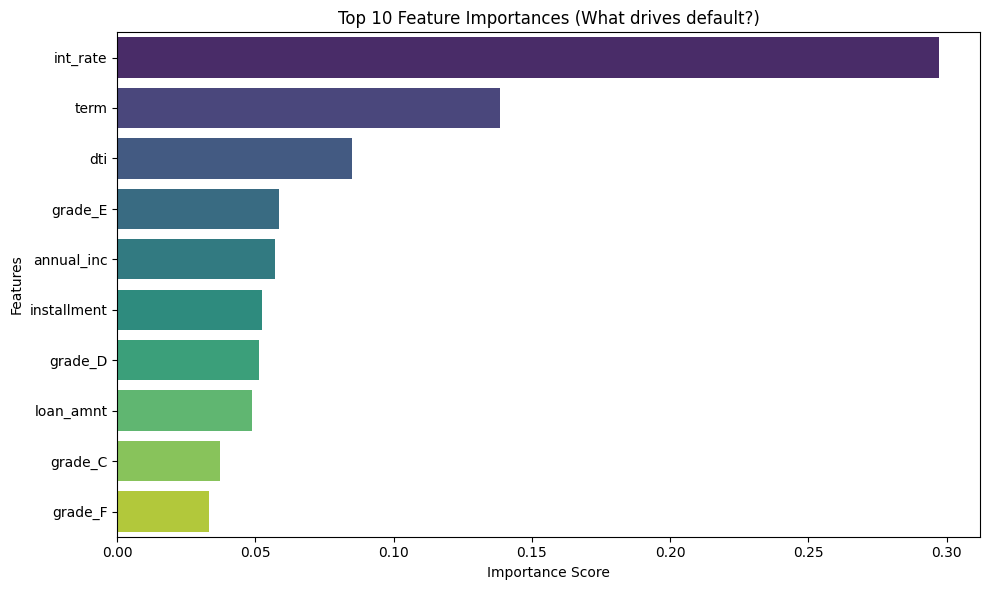

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

# สุ่มข้อมูลมา 200,000 บรรทัด เพื่อความรวดเร็วในการ Train Model
# (ใช้ random_state เพื่อให้สุ่มได้ข้อมูลชุดเดิมทุกครั้งที่รัน)
df_sample = df_model.sample(n=200000, random_state=42)

# แบ่งข้อมูลเป็น X (ตัวแปรต้น/ข้อสอบ) และ y (ตัวแปรตาม/เฉลย)
X = df_sample.drop('target', axis=1)
y = df_sample['target']

# แบ่งข้อมูลเป็นชุด Train (ให้โมเดลเรียน) 80% และชุด Test (ไว้สอบวัดผล) 20%
# stratify=y คือการบังคับให้สัดส่วนหนี้เสีย 20% กระจายไปในชุดเรียนและชุดสอบเท่าๆ กัน
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"จำนวนข้อมูลสำหรับ Train: {X_train.shape[0]} บรรทัด")
print(f"จำนวนข้อมูลสำหรับ Test: {X_test.shape[0]} บรรทัด")

# สร้างและ Train โมเดล Random Forest
# (เปรียบเสมือนการสร้างต้นไม้ตัดสินใจหลายๆ ต้นมาช่วยกันโหวต)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# ดึงค่าความสำคัญของตัวแปร (Feature Importance) ออกมาจากโมเดล
importances = rf_model.feature_importances_

# สร้าง DataFrame เพื่อจัดเรียงและพล็อตให้สวยงาม
feature_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# พล็อตการฟดู Top 10 ตัวแปรที่มีผลมากที่สุด
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_df.head(10), palette='viridis')
plt.title('Top 10 Feature Importances (What drives default?)')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

รายงานผลสอบของโมเดล (Classification Report):
              precision    recall  f1-score   support

           0       0.80      0.99      0.89     31921
           1       0.53      0.03      0.06      8079

    accuracy                           0.80     40000
   macro avg       0.66      0.51      0.48     40000
weighted avg       0.75      0.80      0.72     40000



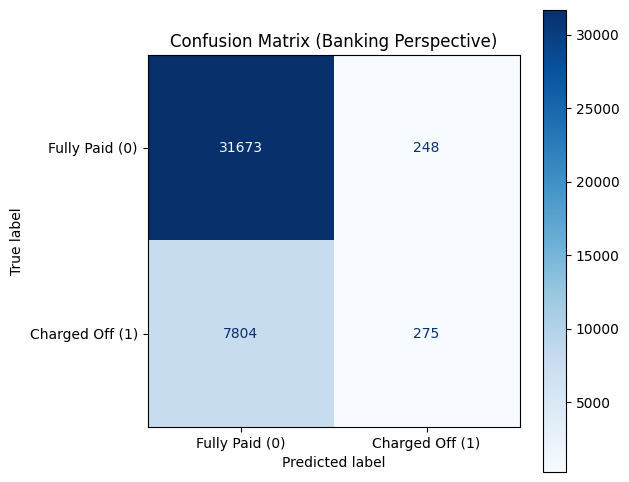

In [17]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# ให้โมเดลทำนายข้อสอบ (ชุด Test ที่เราเก็บไว้ 20% หรือ 40,000 คน)
y_pred = rf_model.predict(X_test)

# ดูภาพรวมความแม่นยำ (Classification Report)
print("รายงานผลสอบของโมเดล (Classification Report):")
print(classification_report(y_test, y_pred))

# พล็อต Confusion Matrix (ตารางแจกแจงการทายผล)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fully Paid (0)', 'Charged Off (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d', ax=ax)
plt.title('Confusion Matrix (Banking Perspective)')
plt.show()

In [18]:
# สร้างตัวแปร Payment-to-Income (ค่างวดต่อเดือน / รายได้ต่อเดือน)
# ต้องระวังกรณีที่ annual_inc เป็น 0 (ถึงจะน้อยแต่กัน Error ไว้ก่อน) โดยบวกค่าเล็กๆ (0.01) เข้าไปเป็นตัวหาร
df_sample['pti_ratio'] = df_sample['installment'] / ((df_sample['annual_inc'] / 12) + 0.01)

# สร้างตัวแปร Loan-to-Income (วงเงินกู้ / รายได้ต่อปี)
df_sample['loan_to_income'] = df_sample['loan_amnt'] / (df_sample['annual_inc'] + 0.01)

# ดูผลลัพธ์ตัวแปรใหม่ที่เราเพิ่งสร้างขึ้นมา
print("ตัวอย่างข้อมูลที่มี Feature ใหม่ (pti_ratio และ loan_to_income):")
display(df_sample[['installment', 'annual_inc', 'pti_ratio', 'loan_amnt', 'loan_to_income']].head())

ตัวอย่างข้อมูลที่มี Feature ใหม่ (pti_ratio และ loan_to_income):


,installment,annual_inc,pti_ratio,loan_amnt,loan_to_income
1509134,99.32,41000.0,0.029069,3200,0.078049
1005063,270.25,80000.0,0.040537,8000,0.100000
1794390,793.84,150000.0,0.063507,25000,0.166667
1261656,191.28,51000.0,0.045007,6000,0.117647
1033094,1207.30,200000.0,0.072438,35000,0.175000


In [19]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import pandas as pd

# แบ่ง X (ตัวแปรต้น) และ y (เป้าหมาย) อีกครั้ง เพราะเรามี Feature ใหม่เพิ่มเข้ามา
X_new = df_sample.drop('target', axis=1)
y_new = df_sample['target']

# แบ่งข้อมูล Train 80% / Test 20% เหมือนเดิม
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y_new, test_size=0.2, random_state=42, stratify=y_new
)

print(f"ก่อนทำ SMOTE - จำนวนข้อมูล Train: หนี้ดี = {(y_train_new == 0).sum()}, หนี้เสีย = {(y_train_new == 1).sum()}")

smote = SMOTE(random_state=42)

# นำ SMOTE มาสร้างข้อมูลจำลอง "เฉพาะบน X_train และ y_train"
X_train_smote, y_train_smote = smote.fit_resample(X_train_new, y_train_new)

print(f"หลังทำ SMOTE - จำนวนข้อมูล Train: หนี้ดี = {(y_train_smote == 0).sum()}, หนี้เสีย = {(y_train_smote == 1).sum()}")

ก่อนทำ SMOTE - จำนวนข้อมูล Train: หนี้ดี = 127682, หนี้เสีย = 32318
หลังทำ SMOTE - จำนวนข้อมูล Train: หนี้ดี = 127682, หนี้เสีย = 127682


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:08:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.81      0.97      0.88     31921
           1       0.47      0.11      0.18      8079

    accuracy                           0.80     40000
   macro avg       0.64      0.54      0.53     40000
weighted avg       0.74      0.80      0.74     40000



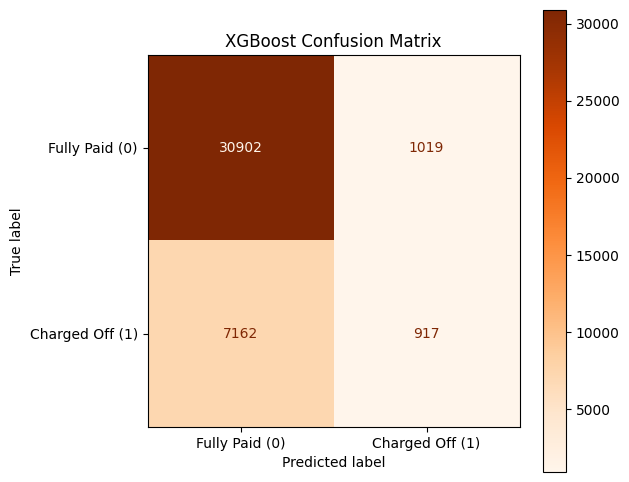

In [20]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# สร้างและ Train โมเดล XGBoost ด้วยข้อมูลที่ผ่านการทำ SMOTE มาแล้ว
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train_smote, y_train_smote)


# ให้โมเดลลองทำนายข้อสอบ (ชุด Test ที่ไม่ได้ทำ SMOTE เพื่อจำลองโลกความจริง)
y_pred_xgb = xgb_model.predict(X_test_new)

# ดูภาพรวมความแม่นยำ
print(classification_report(y_test_new, y_pred_xgb))

# พล็อต Confusion Matrix
cm_xgb = confusion_matrix(y_test_new, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['Fully Paid (0)', 'Charged Off (1)'])

fig, ax = plt.subplots(figsize=(6, 6))
disp_xgb.plot(cmap='Oranges', values_format='d', ax=ax) # เปลี่ยนสีเป็นสีส้มให้รู้ว่าเป็น XGBoost
plt.title('XGBoost Confusion Matrix')
plt.show()

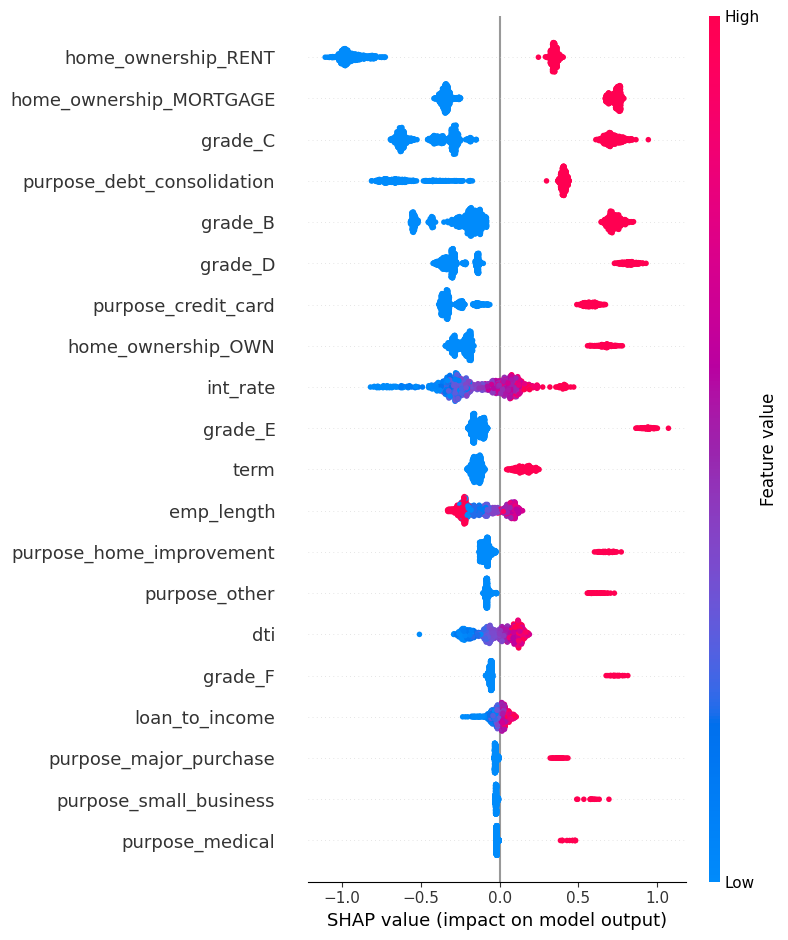

In [21]:
!pip install shap -q
import shap

# สร้าง Explainer เพื่อแกะกล่อง XGBoost
explainer = shap.TreeExplainer(xgb_model)

# คำนวณค่า SHAP เฉพาะกลุ่ม Test 1,000 คนแรกเพื่อประหยัดเวลา
shap_values = explainer.shap_values(X_test_new[:1000])


plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_new[:1000], plot_type="dot")